# Health, Habits, and Cancer: Examining Risk of Cancer Using Support Vector Machines 

The following project is designed to predict the presence of cancer based on demographic and health data using support vector machines. In accounting for potential nonlinear relationships between predictors and whether an individual has or has had cancer, three separate forms of support vector machines were applied:

1) **Linear kernel**: using a linear decision boundary to determine whether a given individual has or has had cancer
2) **Radial kernel**: using a circular-like decision boundary
3) **Polynomial kernel**: using a curved decision boundary 

The data used for this project was collected from the 2022 National Health Interview Survey and contains a wide variety of responses to survey questions regarding the respondents' demographic backgrounds, health metrics and habits, as well as personal history with disease (e.g. cancer, heart disease, etc.). A total of 7 predictor variables were chosen to examine their relationship with cancer: age, ratio of family income to poverty threshold, body mass index, health insurance coverage status, frequency of alcohol consumption in the past year, duration of moderate activity lasting longer than 10 minutes, and usual hours of sleep per day. In order for the support vector models to better handle the data, which initially contained upwards of 35,000 observations, the set was reduced to examine only individuals above the age of 21 and from the American South (designated as region 3). 

Dataset and codebook: \
Lynn A. Blewett, Julia A. Rivera Drew, Miriam L. King, Kari C.W. Williams, Daniel Backman, Annie Chen, and Stephanie Richards. IPUMS Health Surveys: National Health Interview Survey, Version 7.4 [dataset]. Minneapolis, MN: IPUMS, 2024. https://doi.org/10.18128/D070.V7.4. http://www.nhis.ipums.org

## Import necessary libraries

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, cm
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection as skm
from sklearn.model_selection import train_test_split, GridSearchCV
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay
roc_curve = RocCurveDisplay.from_estimator

## Load data and generate DataFrame

In [2]:
health = pd.read_csv("C:/Users/jacob/Downloads/nhis_2022.csv")
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35115 entries, 0 to 35114
Data columns (total 48 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         35115 non-null  int64  
 1   SERIAL       35115 non-null  int64  
 2   STRATA       35115 non-null  int64  
 3   PSU          35115 non-null  int64  
 4   NHISHID      35115 non-null  object 
 5   REGION       35115 non-null  int64  
 6   PERNUM       35115 non-null  int64  
 7   NHISPID      35115 non-null  object 
 8   HHX          35115 non-null  object 
 9   SAMPWEIGHT   35115 non-null  float64
 10  ASTATFLG     35115 non-null  int64  
 11  CSTATFLG     35115 non-null  int64  
 12  AGE          35115 non-null  int64  
 13  SEX          35115 non-null  int64  
 14  MARSTCUR     35115 non-null  int64  
 15  EDUC         35115 non-null  int64  
 16  HOURSWRK     35115 non-null  int64  
 17  POVERTY      35115 non-null  int64  
 18  HEIGHT       35115 non-null  int64  
 19  WEIG

### Preparing Target Variable

The chosen target variable for this analysis is CANCEREV, with respondents either having or not having cancer represented by either 2's or 1's respectively. The remaining values represent a lack of response or the question not being asked to specific respondents (i.e. children). This variable will be cleaned to remove these non-responses and a new variable CANCER is made to adjust the remaining values to a binary format.

In [3]:
# determine value counts for CANCEREV variable
health['CANCEREV'].value_counts(dropna=False).sort_index() 

CANCEREV
0     7464
1    24184
2     3430
7       28
9        9
Name: count, dtype: int64

In [4]:
health = health[health['CANCEREV'].isin([1, 2])].copy() # remove 0s, 7s, and 9s from CANCEREV column
health['CANCER'] = (health['CANCEREV'] == 2).astype(int) # convert to binary format

In [5]:
health['CANCER'].value_counts(dropna=False).sort_index() # verify binary format

CANCER
0    24184
1     3430
Name: count, dtype: int64

Upon verifying the binary format of the CANCER variable, it is clear that there is significant class imbalance between the cancer and non-cancer classes. The respondents who have or have had cancer number at 3,430 compared to those who have never had cancer totaling 24,184. This class imbalance will have to be accounted for when applying the support vector machines.

Lastly, the remaining disease columns will be dropped so as to not interfere with the CANCER variable.

In [6]:
health = health.drop(columns=['CHEARTDIEV', 'DIABETICEV', 'HEARTATTEV', 'STROKEV'])

### Preparing Predictor Variables

The primary predictor variables of interest that will be considered are age (AGE), ratio of family income to poverty threshold (POVERTY), body mass index (BMICALC), health insurance coverage status (HINOTCOVE), frequency of alcohol consumption in the past year in number of units (ALCANYNO), duration of moderate activity lasting longer than 10 minutes (MOD10DMIN), and usual hours of sleep per day (HRSLEEP). 

Given that one of the variables considered concerns alcohol consumption, the data is filtered to only consider respondents of 21 years of age or above. Additionally, to further reduce the number of observations the support vector machines will be handling, the dataset is further reduced to only include respondents from the American South (designated as region 3 in the survey).

In [7]:
health = health[health['AGE'] >= 21].copy()
health = health[health['REGION'] == 3].copy()

Next, each predictor variable is inspected for sentinel values that will need to be removed prior to analysis. Each sentinel value is converted to a null value which are then collectively removed from the DataFrame.

In [8]:
predictors = ['AGE', 'POVERTY', 'BMICALC', 'HINOTCOVE', 'ALCANYNO', 'MOD10DMIN', 'HRSLEEP']

for predictor in predictors:
    print(f"\n{predictor}:")
    print(health[predictor].value_counts(dropna=False).sort_index())


AGE:
AGE
21      85
22      95
23     115
24     112
25     129
      ... 
83      72
84      73
85     364
997     22
999      2
Name: count, Length: 67, dtype: int64

POVERTY:
POVERTY
11     315
12     361
13     490
21     513
22     521
23     405
24     529
31     905
32     733
33     637
34     615
35     524
36     558
37    2843
Name: count, dtype: int64

BMICALC:
BMICALC
15.2       1
15.4       1
16.3       1
16.5       1
16.6       2
        ... 
49.2       1
50.8       1
51.9       1
52.3       1
996.0    854
Name: count, Length: 314, dtype: int64

HINOTCOVE:
HINOTCOVE
1    8868
2    1054
9      27
Name: count, dtype: int64

ALCANYNO:
ALCANYNO
0      2043
1      1770
2      1713
3       894
4       465
5       400
6       189
7       414
8        31
9         9
10      116
11        2
12       69
14        7
15       33
16        3
17        1
20       30
21        1
24       12
25        7
26        5
28        1
30       33
35        1
36        2
40        5
45        1

In [9]:
health['AGE'] = health['AGE'].replace([997, 999], np.nan)
health['BMICALC'] = health['BMICALC'].replace(996.0, np.nan)
health['HINOTCOVE'] = health['HINOTCOVE'].replace(9, np.nan).map({1: 1, 2: 0}) # mapping insurance coverage to binary format
health['ALCANYNO'] = health['ALCANYNO'].replace([996, 997, 998, 999], np.nan)
health['MOD10DMIN'] = health['MOD10DMIN'].replace([996, 997, 998, 999], np.nan)
health['HRSLEEP'] = health['HRSLEEP'].replace([97, 98, 99], np.nan)

In [10]:
health = health[predictors + ['CANCER']].dropna() # drop all null values from DataFrame 

In [11]:
health.isna().sum() # verify lack of null values

AGE          0
POVERTY      0
BMICALC      0
HINOTCOVE    0
ALCANYNO     0
MOD10DMIN    0
HRSLEEP      0
CANCER       0
dtype: int64

In [12]:
health.shape

(7571, 8)

The dataset has been reduced from 35,000+ observations down to 7,571, which can then be used for assessing the support vector machines.

## Exploratory Data Analysis

The relationships between the predictor variables and the target variable are further examined using correlation matrices and scatter plots.

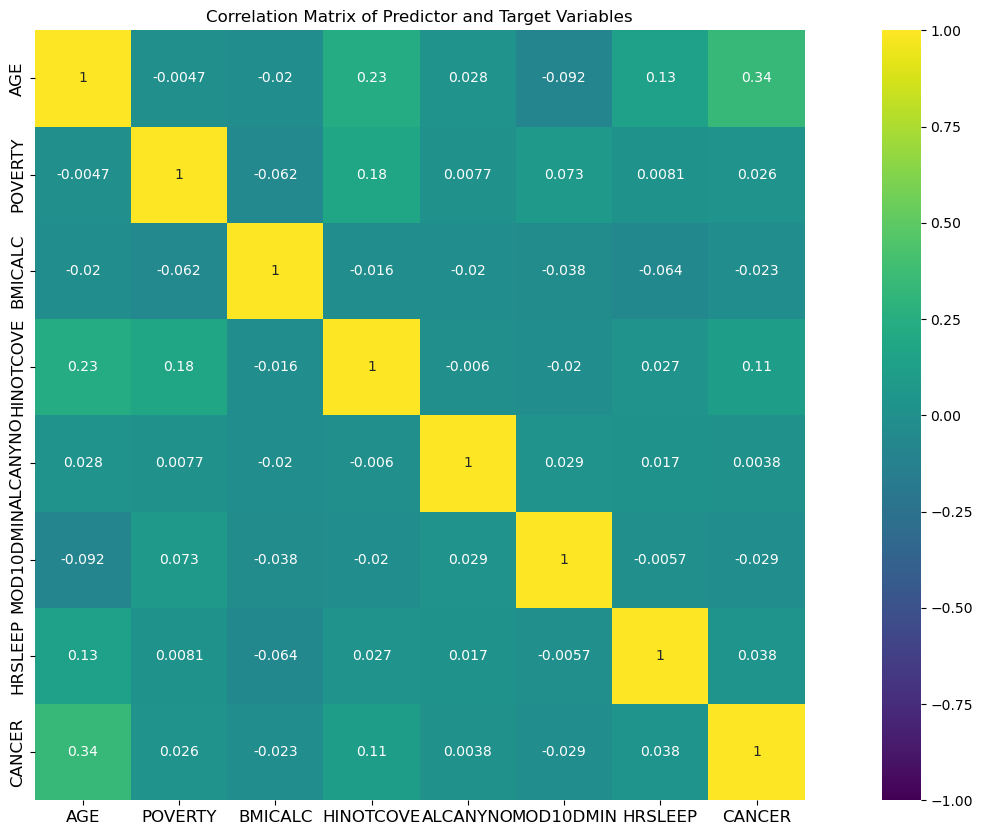

In [46]:
corr_matrix = health[predictors + ['CANCER']].corr()

plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap='viridis'
)

plt.tick_params(labelsize=12)
plt.title('Correlation Matrix of Predictor and Target Variables')
plt.show()

In [45]:
# print correlation coefficients for each of the predictors relative to target variable
predictor_correlations = health.corr()['CANCER'].sort_values()
predictor_correlations

MOD10DMIN   -0.028647
BMICALC     -0.023493
ALCANYNO     0.003788
POVERTY      0.026453
HRSLEEP      0.037802
HINOTCOVE    0.105317
AGE          0.336127
CANCER       1.000000
Name: CANCER, dtype: float64

The correlation matrix and correlation coefficients above convey that the two variables with the strongest relationship to the target variable of CANCER are age (AGE) and whether they have health insurance coverage (HINOTCOVE).

This plot below examines the relationship between age and body mass index, with data points colored based on which of the cancer classes they belong to -- 'no cancer' in blue, 'cancer' in red.

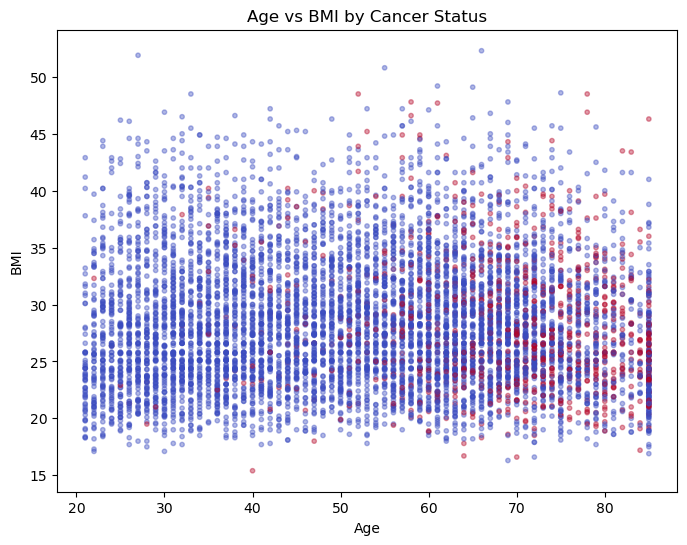

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(health['AGE'], health['BMICALC'],
            c=health['CANCER'], cmap='coolwarm', alpha=0.4, s=10)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI by Cancer Status')
plt.show()

The bar plot below examines the rate of cancer diagnosis across various income levels. 

<Axes: xlabel='POVERTY'>

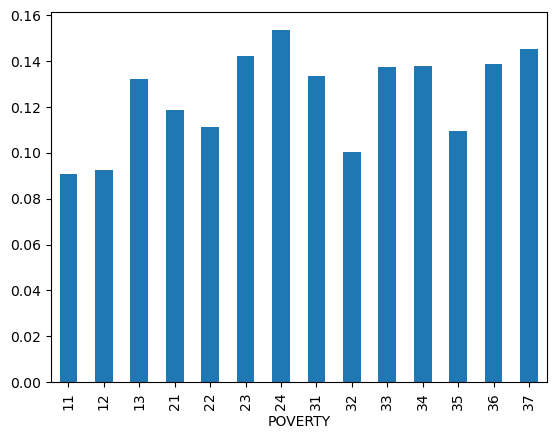

In [15]:
health.groupby('POVERTY')['CANCER'].mean().plot(kind='bar')

Based on the output, the rate of cancer occurrence has no clear pattern across the income statuses, but there is noticeably lower rates in the lowest income groups (closer to the poverty line).

The KDE plot below provides two curves for the density of cancer status relative to age (no cancer in blue and cancer in orange).

CANCER
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
Name: AGE, dtype: object

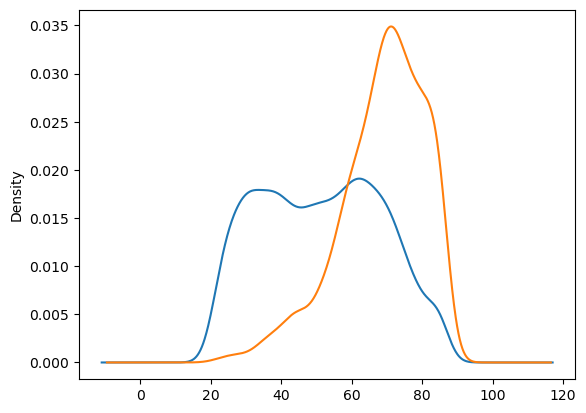

In [16]:
health.groupby('CANCER')['AGE'].plot(kind='kde')

Based on the curves, like with the correlation matrix, the occurrence of cancer appears to be most dense between ages of 60 and 90.

## Train-Test Split and Feature Scaling

The code below first defines the predictor and target variables before splitting the dataset into training and test sets representing 80 and 20% of data points, respectively. The data is then scaled using the ``StandardScaler`` tool, which will help to prevent any of the predictor variables from dominating the models.

In [19]:
# define predictor variables and target variable
X = health[predictors]
y = health['CANCER']

In [20]:
# split the data between test and train
# stratify applied to ensure train and test sets have same class breakdown as original data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.8,
                                                    random_state=1,
                                                    stratify=y)

In [22]:
# scale the data and save as DataFrame
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

## Support Vector Machine with Linear Kernel

A support vector machine with a linear kernel is then fit to the training data. Using cross-validation, the optimal hyperparameters are determined and used to generate an optimal model.

In [23]:
# fit SVM with linear kernel
svm_linear = SVC(kernel='linear', class_weight='balanced') # balanced argument to account for class imbalance
svm_linear.fit(X_train, y_train)

# 5-fold cross-validation along with grid search across 5 different cost values
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid_linear = skm.GridSearchCV(svm_linear,
                        {'C':[0.01,0.1,1,5,10]}, # potential cost values
                        refit=True,
                        cv=kfold,
                        scoring='roc_auc',
                        n_jobs=-1) # roc_auc scoring to ensure model doesn't bias to majority class
grid_linear.fit(X_train, y_train)
grid_linear.best_params_

{'C': 10}

In [24]:
# support points
svm_linear.n_support_.sum()

np.int64(3810)

The code blocks below will generate training and test errors for both the untuned and tuned linear kernel models.

In [25]:
# training error rate
y_pred_linear = svm_linear.predict(X_train)
training_error_linear = np.mean(y_pred_linear != y_train)
# test error rate
y_pred_test_linear = svm_linear.predict(X_test)
test_error_linear = np.mean(y_pred_test_linear != y_test)
training_error_linear, test_error_linear

(np.float64(0.3503963011889036), np.float64(0.3438943894389439))

In [26]:
# training error rate
y_pred_linear2 = grid_linear.predict(X_train)
training_error_linear2 = np.mean(y_pred_linear2 != y_train)
# test error rate
y_pred_test_linear2 = grid_linear.predict(X_test)
test_error_linear2 = np.mean(y_pred_test_linear2 != y_test)
training_error_linear2, test_error_linear2

(np.float64(0.3502311756935271), np.float64(0.3438943894389439))

The tuned model appears to have not generated any significant improvements in error training and test error rate. A comparison of the ROC curves between the training and test data for this model is shown below.

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


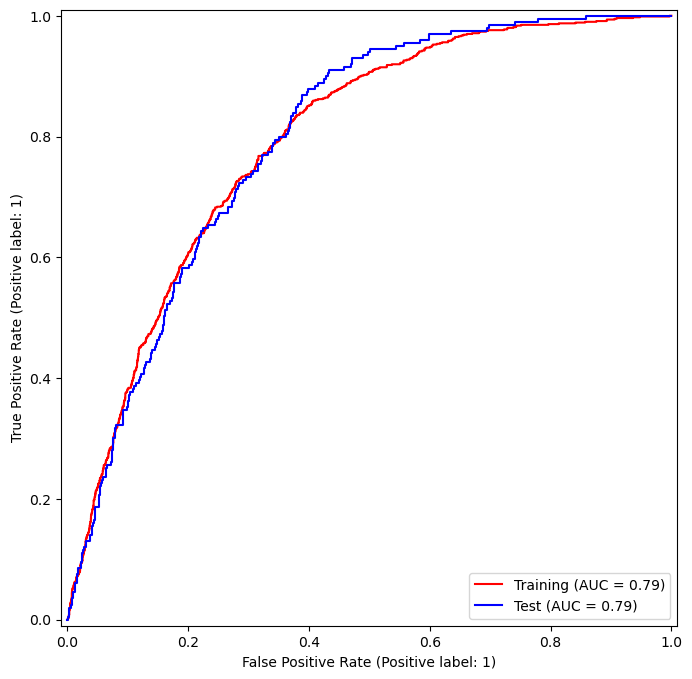

In [27]:
fig, ax = subplots(figsize=(8,8))
roc_curve(grid_linear,
          X_train,
          y_train,
          name='Training',
          color='r',
          ax=ax);
roc_curve(grid_linear,
          X_test,
          y_test,
          name='Test',
          color='b',
          ax=ax);

The following code generates a support vector classifier examining only two predictors (age and BMI) in order to visualize the decision boundary and margins used by the linear kernel model. 

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


KeyError: '[5, 9, 11, 14, 19, 20, 21, 22, 25, 28, 29, 31, 34, 36, 38, 40, 41, 43, 48, 51, 52, 59, 64, 68, 71, 73, 74, 76, 80, 82, 83, 84, 87, 89, 91, 94, 100, 101, 102, 103, 105, 108, 110, 111, 116, 117, 121, 124, 126, 129, 132, 135, 137, 143, 144, 148, 150, 158, 166, 173, 174, 175, 177, 180, 181, 183, 188, 192, 193, 195, 199, 200, 205, 206, 209, 211, 212, 213, 215, 223, 225, 226, 231, 232, 233, 234, 235, 236, 237, 239, 240, 249, 252, 254, 255, 256, 258, 259, 263, 265, 266, 268, 273, 275, 277, 280, 292, 295, 299, 302, 303, 304, 305, 306, 308, 311, 312, 313, 317, 327, 329, 330, 331, 332, 334, 336, 337, 338, 341, 345, 347, 348, 349, 356, 359, 361, 363, 366, 371, 377, 378, 379, 380, 381, 384, 390, 392, 394, 395, 397, 401, 403, 404, 406, 411, 415, 416, 417, 419, 421, 425, 428, 430, 432, 436, 438, 439, 440, 441, 442, 447, 448, 449, 451, 452, 456, 460, 463, 465, 466, 468, 469, 470, 471, 477, 478, 479, 480, 482, 484, 492, 495, 496, 497, 498, 501, 504, 505, 506, 507, 516, 518, 521, 522, 524, 5

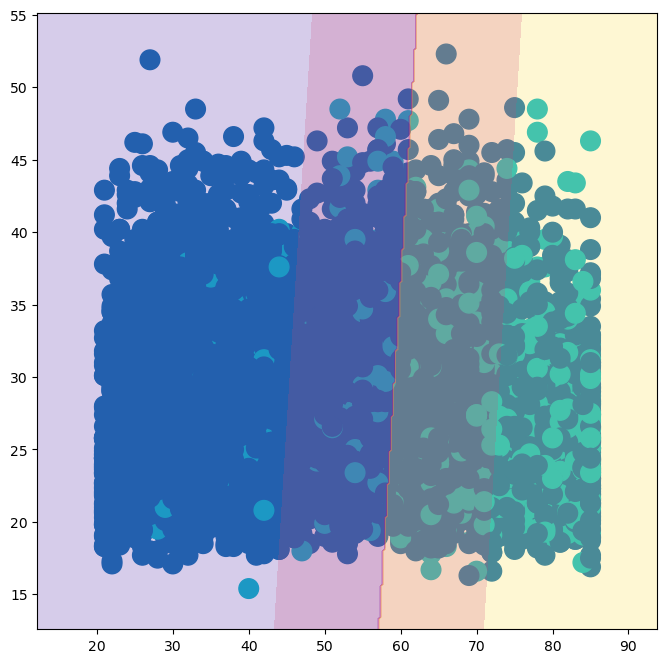

In [30]:
# 2 feature model for visualization purposes only
predictors2 = ['AGE', 'BMICALC']
X2 = health[predictors2]
y2 = health['CANCER']

svm_linear_2 = SVC(kernel='linear', 
                    class_weight='balanced',
                    C=grid_linear.best_params_['C'])
svm_linear_2.fit(X2, y2)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X2, y2, svm_linear_2, ax=ax)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI with Decision Boundary for Cancer Class')

From the ROC curves, the model appears to be consistent with handling both training and test data and does not broadly overfit the training data. The decision boundary plot shows that age is more correlated with cancer class compared to BMI, with a majority of cancer cases occurring with higher ages.

## Support Vector Machine with Radial Kernel

In [31]:
# fit SVM with radial kernel
svm_radial = SVC(kernel='rbf', class_weight='balanced') 
svm_radial.fit(X_train, y_train)

# 5-fold cross-validation along with grid search across multiple values of cost and gamma
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid_radial = skm.GridSearchCV(svm_radial,
                        {'C':[0.01,0.1,1,5,10],
                        'gamma':[0.0001,0.001,0.01,0.1,1]},
                        refit=True,
                        cv=kfold,
                        scoring='roc_auc',
                        n_jobs=-1)
grid_radial.fit(X_train, y_train)
grid_radial.best_params_

{'C': 10, 'gamma': 0.001}

In [32]:
# support points
svm_radial.n_support_.sum()

np.int64(3652)

The code blocks below will generate training and test errors for both the untuned and tuned radial kernel models.

In [33]:
# training error rate
y_pred_radial = svm_radial.predict(X_train)
training_error_radial = np.mean(y_pred_radial != y_train)
# test error rate
y_pred_test_radial = svm_radial.predict(X_test)
test_error_radial = np.mean(y_pred_test_radial != y_test)
training_error_radial, test_error_radial

(np.float64(0.33702113606340817), np.float64(0.3465346534653465))

In [34]:
# training error rate
y_pred_radial2 = grid_radial.predict(X_train)
training_error_radial2 = np.mean(y_pred_radial2 != y_train)
# test error rate
y_pred_test_radial2 = grid_radial.predict(X_test)
test_error_radial2 = np.mean(y_pred_test_radial2 != y_test)
training_error_radial2, test_error_radial2

(np.float64(0.35402906208718626), np.float64(0.34917491749174917))

The tuned radial model appears to have a subtly worse performance in terms of accuracy. A comparison of the ROC curves between the training and test data for this model is shown below.

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


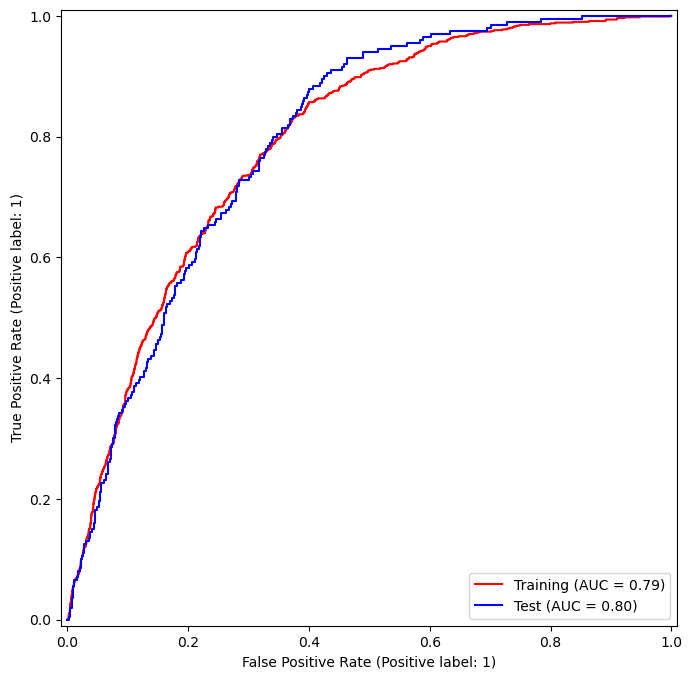

In [35]:
fig, ax = subplots(figsize=(8,8))
roc_curve(grid_radial,
          X_train,
          y_train,
          name='Training',
          color='r',
          ax=ax);
roc_curve(grid_radial,
          X_test,
          y_test,
          name='Test',
          color='b',
          ax=ax);

The following code again generates a support vector classifier examining only two predictors (age and BMI) to visualize the decision boundary and margins used by the radial kernel model. 

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


KeyError: '[5, 11, 14, 19, 20, 21, 22, 25, 28, 29, 31, 34, 36, 38, 40, 43, 48, 49, 51, 52, 59, 64, 66, 67, 68, 73, 76, 82, 83, 84, 87, 89, 91, 94, 98, 100, 101, 102, 103, 105, 108, 110, 111, 116, 117, 121, 124, 126, 129, 132, 135, 137, 138, 143, 144, 148, 150, 158, 161, 162, 166, 173, 174, 175, 177, 180, 181, 183, 188, 192, 193, 195, 199, 200, 202, 205, 206, 207, 212, 213, 223, 225, 231, 232, 233, 234, 235, 236, 237, 239, 240, 249, 252, 254, 255, 256, 257, 258, 259, 263, 265, 266, 267, 268, 273, 275, 277, 280, 290, 292, 297, 299, 302, 303, 304, 305, 306, 308, 311, 312, 313, 327, 329, 330, 331, 332, 334, 336, 337, 338, 341, 345, 347, 348, 349, 350, 357, 359, 360, 361, 363, 366, 371, 375, 377, 378, 379, 380, 381, 387, 390, 392, 394, 395, 397, 401, 403, 404, 406, 409, 411, 415, 416, 419, 421, 425, 428, 432, 436, 438, 439, 440, 442, 444, 447, 448, 449, 451, 456, 460, 463, 465, 466, 468, 469, 470, 471, 477, 478, 479, 480, 482, 484, 491, 492, 496, 497, 498, 501, 504, 506, 507, 511, 516, 518,

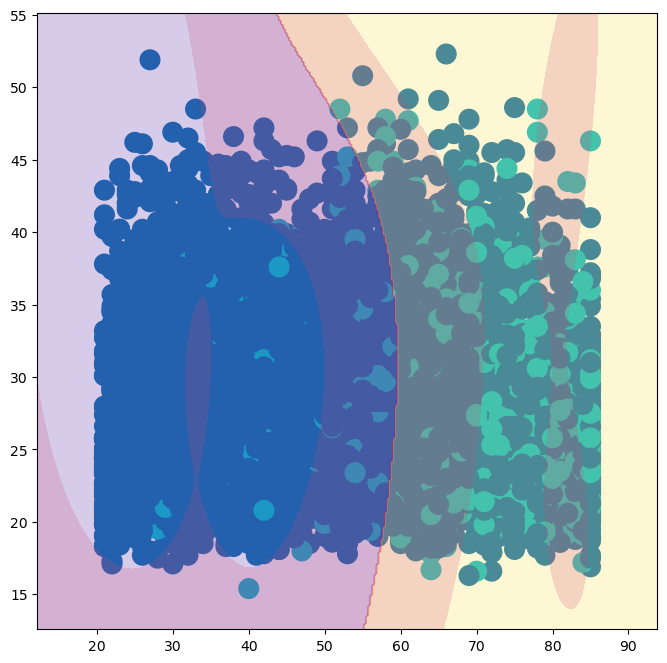

In [36]:
# 2 feature model for visualization purposes only
predictors2 = ['AGE', 'BMICALC']
X2 = health[predictors2]
y2 = health['CANCER']

svm_radial_2 = SVC(kernel='rbf', 
                    class_weight='balanced',
                    C=grid_radial.best_params_['C'],
                    gamma=grid_radial.best_params_['gamma'])
svm_radial_2.fit(X2, y2)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X2, y2, svm_radial_2, ax=ax)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI with Decision Boundary for Cancer Class')

From the ROC curves, the radial model also appears to be consistent with handling both training and test data. The decision boundary plot shows that age is more correlated with cancer class compared to BMI, again with the data points classified as cancer falling toward higher ages.

## Support Vector Machine with Polynomial Kernel

In [37]:
# fit SVM with polynomial kernel
svm_poly = SVC(kernel='poly', class_weight='balanced') 
svm_poly.fit(X_train, y_train)

# 5-fold cross-validation along with grid search across multiple values of cost and degree
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid_poly = skm.GridSearchCV(svm_poly,
                        {'C':[0.01,0.1,1,5,10],
                        'degree':[2,3]},
                        refit=True,
                        cv=kfold,
                        scoring='roc_auc',
                        n_jobs=-1)
grid_poly.fit(X_train, y_train)
grid_poly.best_params_

{'C': 10, 'degree': 2}

In [38]:
# support points
svm_poly.n_support_.sum()

np.int64(4223)

The code blocks below will generate training and test errors for both the untuned and tuned polynomial kernel models.

In [39]:
# training error rate
y_pred_poly = svm_poly.predict(X_train)
training_error_poly = np.mean(y_pred_poly != y_train)
# test error rate
y_pred_test_poly = svm_poly.predict(X_test)
test_error_poly = np.mean(y_pred_test_poly != y_test)
training_error_poly, test_error_poly

(np.float64(0.27031043593130777), np.float64(0.27722772277227725))

In [40]:
# training error rate
y_pred_poly2 = grid_poly.predict(X_train)
training_error_poly2 = np.mean(y_pred_poly2 != y_train)
# test error rate
y_pred_test_poly2 = grid_poly.predict(X_test)
test_error_poly2 = np.mean(y_pred_test_poly2 != y_test)
training_error_poly2, test_error_poly2

(np.float64(0.35535006605019814), np.float64(0.3557755775577558))

The tuned polynomial model appears to have noticeably poorer accuracy compared to the untuned model. A comparison of the ROC curves between the training and test data for the tuned model is shown below.

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


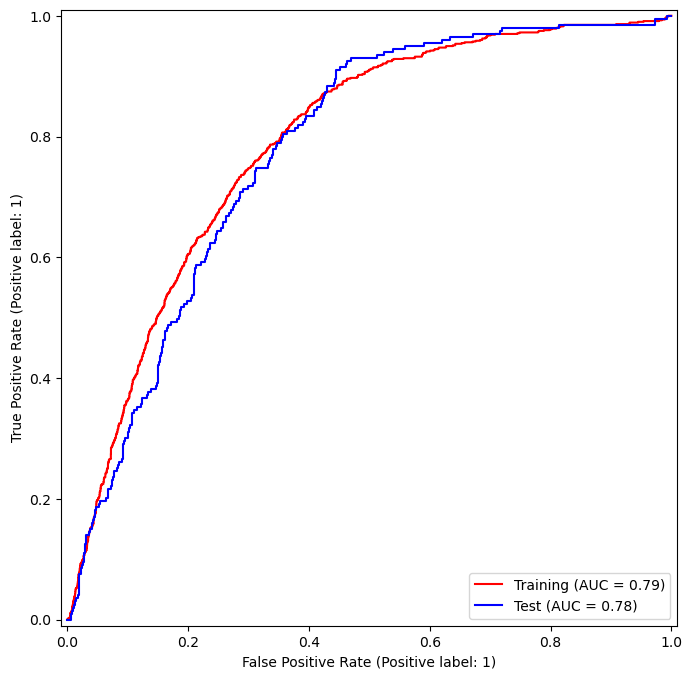

In [41]:
fig, ax = subplots(figsize=(8,8))
roc_curve(grid_poly,
          X_train,
          y_train,
          name='Training',
          color='r',
          ax=ax);
roc_curve(grid_poly,
          X_test,
          y_test,
          name='Test',
          color='b',
          ax=ax);

The code below generates a support vector classifier examining only two predictors (age and BMI) to visualize the decision boundary and margins used by the polynomial kernel model. 

C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
C:\Users\jacob\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


KeyError: '[0, 5, 9, 11, 13, 14, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 34, 36, 38, 40, 41, 43, 46, 48, 51, 52, 59, 64, 67, 68, 71, 73, 76, 80, 82, 83, 84, 87, 89, 91, 94, 100, 101, 102, 103, 105, 108, 110, 111, 116, 117, 121, 124, 126, 129, 132, 135, 137, 143, 144, 148, 150, 158, 161, 162, 164, 166, 168, 172, 173, 174, 175, 177, 180, 181, 183, 192, 193, 195, 199, 200, 202, 205, 206, 207, 209, 212, 213, 223, 225, 226, 228, 231, 232, 233, 234, 235, 236, 237, 239, 240, 249, 252, 254, 255, 256, 258, 259, 263, 265, 266, 267, 268, 273, 275, 277, 280, 292, 295, 297, 299, 302, 303, 304, 305, 306, 308, 311, 312, 313, 319, 327, 329, 330, 331, 332, 334, 336, 337, 338, 341, 345, 347, 348, 349, 350, 356, 359, 360, 361, 363, 366, 371, 377, 378, 379, 380, 381, 384, 390, 392, 394, 395, 397, 401, 403, 404, 406, 410, 411, 415, 416, 417, 419, 421, 425, 428, 430, 432, 436, 438, 439, 440, 441, 442, 444, 447, 448, 449, 451, 452, 456, 460, 463, 465, 466, 468, 469, 470, 471, 477, 478, 479, 480, 482, 484

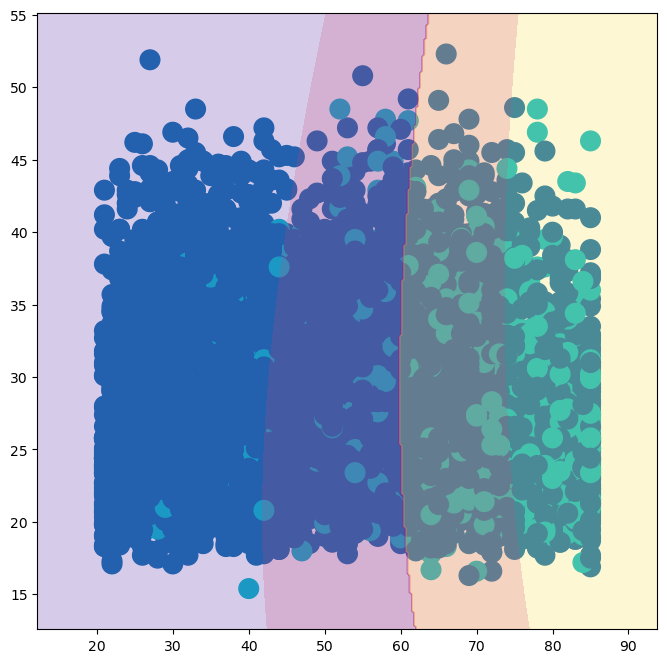

In [42]:
# 2 feature model for visualization purposes only
predictors2 = ['AGE', 'BMICALC']
X2 = health[predictors2]
y2 = health['CANCER']

svm_poly_2 = SVC(kernel='poly', 
                    class_weight='balanced',
                    C=grid_poly.best_params_['C'],
                    degree=grid_poly.best_params_['degree'])
svm_poly_2.fit(X2, y2)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X2, y2, svm_poly_2, ax=ax)
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Age vs BMI with Decision Boundary for Cancer Class')

The polynomial model also appears to be consistent with handling both training and test data when comparing their ROC curves. The decision boundary plot follows a similar pattern to that of the SVM with a linear kernel.

## Model Comparisons

| Kernel Type | Training Error Rate (pre-tuning) | Test Error Rate (pre-tuning) | Training Error Rate (post-tuning) | Test Error Rate (post-tuning) | Train AUC Score | Test AUC Score | Optimal Hyperparameters
|---|---|---|---|---|---|---|---|
| Linear | 35.04% | 34.39% | 35.02% | 34.39% | 0.79 | 0.79 | cost = 10 |
| Radial | 33.70% | 34.65% | 35.40% | 34.92% | 0.79 | 0.80 | cost = 10; gamma = 0.001 |
| Polynomial | 27.03% | 27.72% | 35.54% | 35.58% | 0.79 | 0.78 | cost = 10; degree = 2 |

Based on the final model comparisons, the support vector machine with a radial kernel generalizing the best on unseen data, with a test AUC score of 0.8. Its error rate slightly increased between the untuned and tuned model, suggesting some overfitting may be occurring when using the optimal hyperparameters.

The linear model performed second best, with the second highest test AUC score of 0.79 and error rates remaining roughly the same between the tuned and untuned models. This could suggest that the underlying relationship between the chosen predictors and the target variable of CANCER is broadly linear. This result may be too simplistic and require further investigation.

The polynomial model performed the worst of the three, with the lowest test AUC score of 0.78 as well as the highest error rates of the tuned models. It is worth noting that the tuned model had identifiably worse training and test error rates compared to the untuned model. As such, this model is likely not suitable for modeling the relationship between the predictors and the target variable.

The similar training error rates, test error rates, and AUC scores of all the tuned models might imply that they are limited due to the chosen predictor variables. Consideration of additional predictors may demonstrate more dramatic differences in the capability of the model